# Explainable AI — Phase I: Logical Model

## Payment Difficulty Prediction using a Decision Tree

The objective of this notebook is to develop and interpret a logical model
for predicting `payment_difficulty_next_month`.

The analysis focuses on:

- exploratory data analysis and data quality;
- five-fold cross-validation for model selection;
- the trade-off between predictive performance and interpretability;
- global interpretation of the learned model;
- local explanations for individual predictions.

For Phase I, the logical model is implemented using a decision tree.

In [1]:
%pip install -q numpy pandas matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree,
    export_text
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

RANDOM_STATE = 42

In [5]:
DATA_DIR = Path("../data")

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")

Train shape: (25000, 17)
Test shape:  (5000, 16)


In [6]:
train.head()

,row_id,credit_limit,sex,education,marital_status,age,latest_repayment_status,maximum_repayment_delay_6m,delayed_months_6m,average_bill_6m,bill_change_sep_to_apr,total_payment_6m,payment_to_bill_ratio_6m,zero_payment_months_6m,utilization_sep,repayment_assistance_plan,payment_difficulty_next_month
0,CR26-120473,80000,male,university,married,54,0,0,0,24600,3700,10300,0.07,0,0.33,no,0
1,CR26-127004,20000,male,university,single,30,0,0,0,21100,21000,6700,0.05,0,1.98,no,0
2,CR26-116408,230000,female,graduate_school,married,35,0,0,0,1700,3600,5100,0.49,1,0.03,no,0
3,CR26-125768,150000,female,university,married,51,0,0,0,76100,-8800,15400,0.03,0,0.48,no,0
4,CR26-118040,500000,male,graduate_school,married,43,0,0,0,121600,26200,25000,0.03,0,0.25,yes,0


In [7]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   row_id                         25000 non-null  str    
 1   credit_limit                   25000 non-null  int64  
 2   sex                            25000 non-null  str    
 3   education                      25000 non-null  str    
 4   marital_status                 25000 non-null  str    
 5   age                            25000 non-null  int64  
 6   latest_repayment_status        25000 non-null  int64  
 7   maximum_repayment_delay_6m     25000 non-null  int64  
 8   delayed_months_6m              25000 non-null  int64  
 9   average_bill_6m                25000 non-null  int64  
 10  bill_change_sep_to_apr         25000 non-null  int64  
 11  total_payment_6m               25000 non-null  int64  
 12  payment_to_bill_ratio_6m       25000 non-null  float64
 1

In [8]:
print("Train columns:")
display(train.columns.to_frame(index=False, name="column"))

print("\nColumns only present in train:")
print(set(train.columns) - set(test.columns))

print("\nColumns only present in test:")
print(set(test.columns) - set(train.columns))

Train columns:


,column
0,row_id
1,credit_limit
2,sex
3,education
4,marital_status
5,age
6,latest_repayment_status
7,maximum_repayment_delay_6m
8,delayed_months_6m
9,average_bill_6m



Columns only present in train:
{'payment_difficulty_next_month'}

Columns only present in test:
set()


## 1. Data quality and exploratory analysis

Before fitting the model, we inspect the dataset structure, missing values,
duplicates, target distribution and predictor distributions.

In [31]:
missing = (
    train.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_values")
)

missing["percentage"] = (
    missing["missing_values"] / len(train) * 100
)

missing

,missing_values,percentage
row_id,0,0.0
credit_limit,0,0.0
sex,0,0.0
education,0,0.0
marital_status,0,0.0
age,0,0.0
latest_repayment_status,0,0.0
maximum_repayment_delay_6m,0,0.0
delayed_months_6m,0,0.0
average_bill_6m,0,0.0


In [32]:
print(f"Duplicated rows: {train.duplicated().sum()}")
print(f"Duplicated row_id: {train['row_id'].duplicated().sum()}")

Duplicated rows: 0
Duplicated row_id: 0


In [33]:
TARGET = "payment_difficulty_next_month"

target_counts = train[TARGET].value_counts().sort_index()
target_pct = train[TARGET].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_pct
})

target_summary

,count,percentage
payment_difficulty_next_month,,
0,19697,78.788
1,5303,21.212


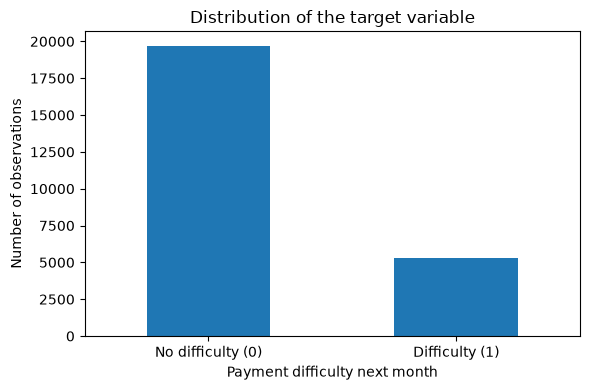

In [34]:
fig, ax = plt.subplots(figsize=(6, 4))

target_counts.plot(kind="bar", ax=ax)

ax.set_title("Distribution of the target variable")
ax.set_xlabel("Payment difficulty next month")
ax.set_ylabel("Number of observations")
ax.set_xticklabels(
    ["No difficulty (0)", "Difficulty (1)"],
    rotation=0
)

plt.tight_layout()
plt.show()

In [35]:
majority_class = train[TARGET].mode()[0]

baseline_predictions = np.full(
    shape=len(train),
    fill_value=majority_class
)

baseline_accuracy = accuracy_score(
    train[TARGET],
    baseline_predictions
)

baseline_balanced_accuracy = balanced_accuracy_score(
    train[TARGET],
    baseline_predictions
)

print(f"Majority class: {majority_class}")
print(f"Baseline accuracy:          {baseline_accuracy:.4f}")
print(f"Baseline balanced accuracy: {baseline_balanced_accuracy:.4f}")

Majority class: 0
Baseline accuracy:          0.7879
Baseline balanced accuracy: 0.5000


In [36]:
ID_COLUMN = "row_id"

X = train.drop(columns=[ID_COLUMN, TARGET])
y = train[TARGET]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (25000, 15)
y shape: (25000,)


In [26]:
categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumeric features:")
print(numeric_features)

Categorical features:
['sex', 'education', 'marital_status', 'repayment_assistance_plan']

Numeric features:
['credit_limit', 'age', 'latest_repayment_status', 'maximum_repayment_delay_6m', 'delayed_months_6m', 'average_bill_6m', 'bill_change_sep_to_apr', 'total_payment_6m', 'payment_to_bill_ratio_6m', 'zero_payment_months_6m', 'utilization_sep']


/tmp/ipykernel_404315/921656930.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [37]:
for column in categorical_features:
    print(f"\n--- {column} ---")

    summary = pd.DataFrame({
        "count": train[column].value_counts(dropna=False),
        "percentage": train[column].value_counts(
            normalize=True,
            dropna=False
        ) * 100
    })

    display(summary)


--- sex ---


,count,percentage
sex,,
female,15130,60.52
male,9870,39.48



--- education ---


,count,percentage
education,,
university,11675,46.700
graduate_school,8820,35.280
high_school,4107,16.428
unknown,289,1.156
other,109,0.436



--- marital_status ---


,count,percentage
marital_status,,
single,13310,53.240
married,11368,45.472
other_or_unknown,322,1.288



--- repayment_assistance_plan ---


,count,percentage
repayment_assistance_plan,,
no,19680,78.72
yes,5320,21.28


In [38]:
numeric_summary = train[numeric_features].describe().T

numeric_summary

,count,mean,std,min,25%,50%,75%,max
credit_limit,25000.0,167740.947200,129975.980819,10000.0,50000.00,140000.00,240000.00,1000000.0
age,25000.0,35.500840,9.243907,21.0,28.00,34.00,41.00,79.0
latest_repayment_status,25000.0,-0.018080,1.120519,-2.0,-1.00,0.00,0.00,8.0
maximum_repayment_delay_6m,25000.0,0.680880,1.070985,0.0,0.00,0.00,2.00,8.0
delayed_months_6m,25000.0,0.833120,1.552059,0.0,0.00,0.00,1.00,6.0
average_bill_6m,25000.0,44910.436000,63267.261940,-56000.0,4700.00,21000.00,57100.00,877300.0
bill_change_sep_to_apr,25000.0,12389.508000,44068.853510,-403600.0,-3000.00,900.00,19900.00,708300.0
total_payment_6m,25000.0,31635.048000,57337.817230,0.0,6700.00,14400.00,33700.00,2314200.0
payment_to_bill_ratio_6m,25000.0,0.374324,0.591434,0.0,0.04,0.09,0.60,5.0
zero_payment_months_6m,25000.0,1.233520,1.722065,0.0,0.00,0.00,2.00,6.0


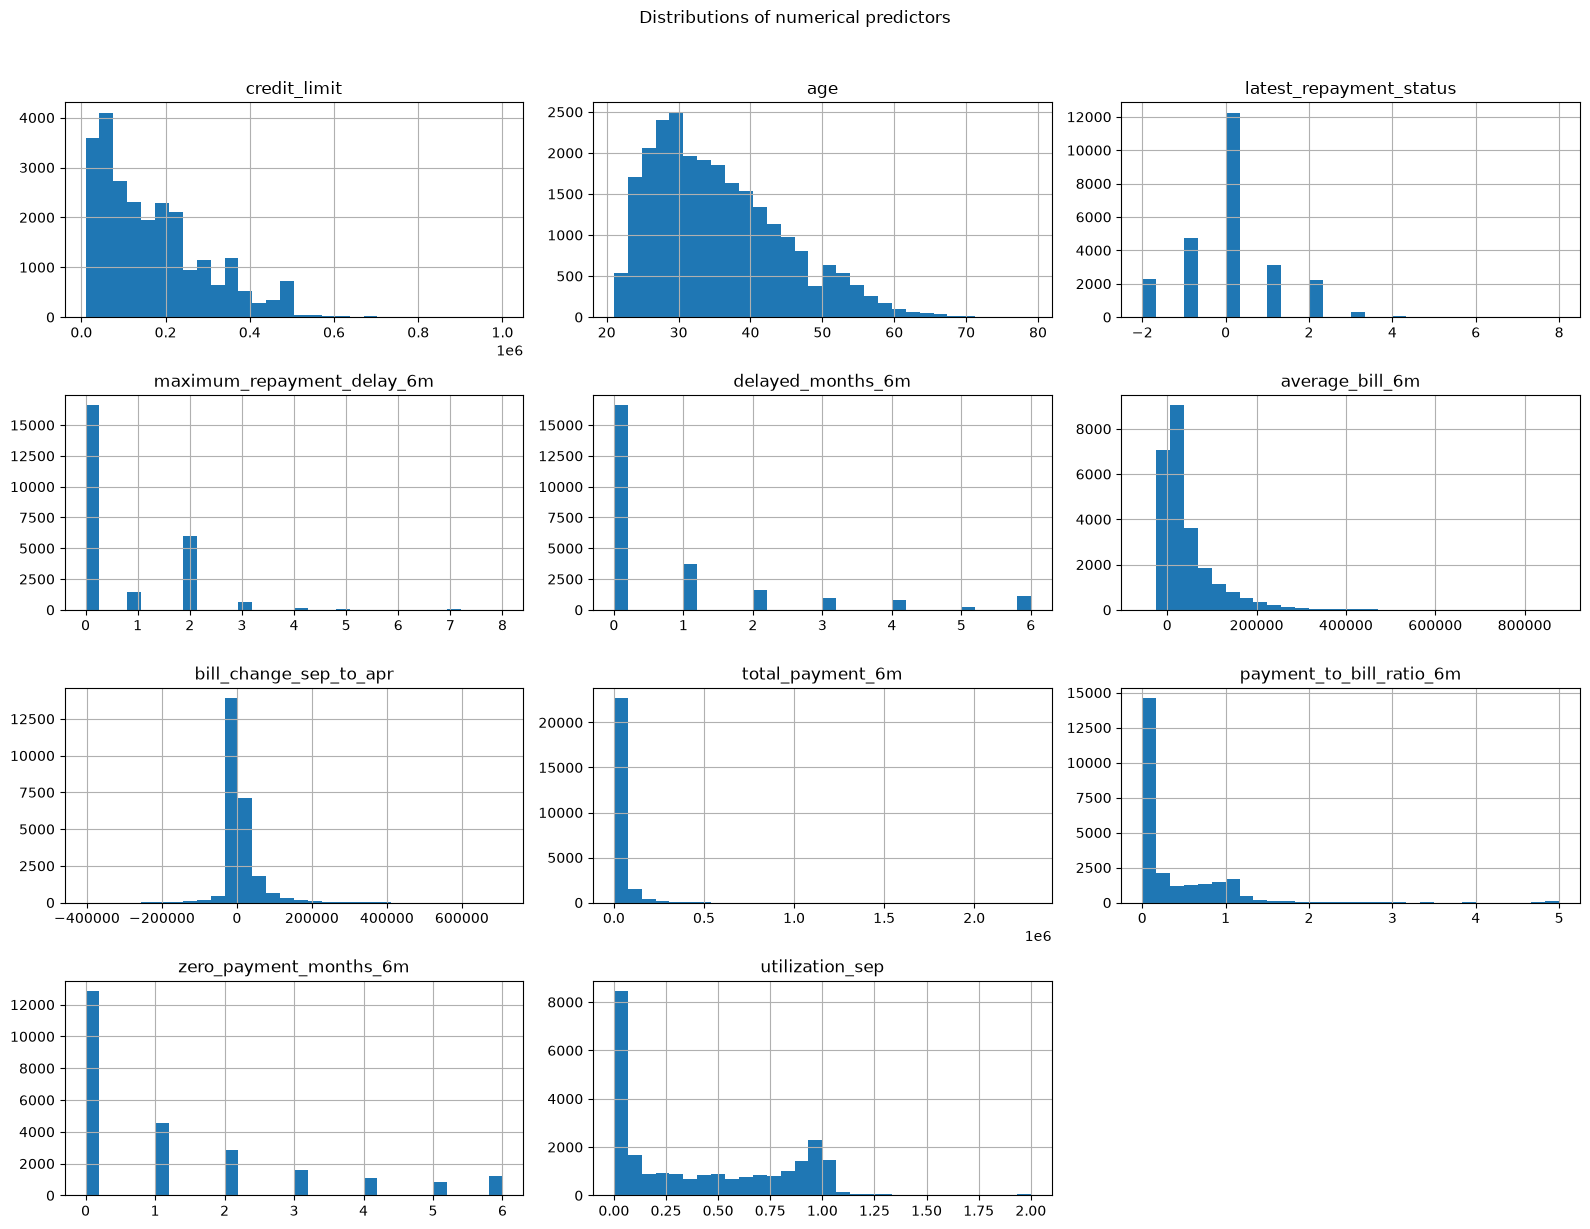

In [39]:
train[numeric_features].hist(
    bins=30,
    figsize=(16, 12)
)

plt.suptitle(
    "Distributions of numerical predictors",
    y=1.02
)

plt.tight_layout()
plt.show()

In [40]:
for column in categorical_features:
    difficulty_rate = (
        train
        .groupby(column, observed=True)[TARGET]
        .agg(["mean", "count"])
        .sort_values("mean", ascending=False)
    )

    difficulty_rate["mean"] *= 100

    difficulty_rate = difficulty_rate.rename(
        columns={"mean": "difficulty_rate_pct"}
    )

    print(f"\n--- {column} ---")
    display(difficulty_rate)


--- sex ---


,difficulty_rate_pct,count
sex,,
male,21.813576,9870
female,20.819564,15130



--- education ---


,difficulty_rate_pct,count
education,,
high_school,23.837351,4107
university,22.064240,11675
unknown,21.453287,289
graduate_school,18.945578,8820
other,13.761468,109



--- marital_status ---


,difficulty_rate_pct,count
marital_status,,
single,21.998497,13310
married,20.328994,11368
other_or_unknown,19.875776,322



--- repayment_assistance_plan ---


,difficulty_rate_pct,count
repayment_assistance_plan,,
yes,32.669173,5320
no,18.114837,19680


### Interpretation caution: repayment assistance

`repayment_assistance_plan` indicates whether a temporary support or
restructuring plan was recorded before the outcome month.

The assignment of assistance is not random. Clients may receive assistance
because the lender has already observed signs of financial stress.

Therefore, differences in payment-difficulty rates between clients with and
without an assistance plan must be interpreted as **predictive associations**,
not as causal effects of receiving assistance.

## 2. Model development strategy

The dataset presents a moderate class imbalance: approximately 79% of the
observations belong to class 0 and 21% to class 1. Therefore, accuracy alone
is not an appropriate criterion for model selection.

Model selection and hyperparameter choices are performed using stratified
five-fold cross-validation. Stratification preserves approximately the class
distribution within each fold.

Categorical predictors are one-hot encoded within the modeling pipeline.
The decision tree does not require feature scaling because its decisions are
based on feature thresholds rather than distances or feature magnitudes.

In [41]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

In [42]:
fold_distributions = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), start=1):
    y_train_fold = y.iloc[train_idx]
    y_val_fold = y.iloc[val_idx]

    fold_distributions.append({
        "fold": fold,
        "train_size": len(train_idx),
        "validation_size": len(val_idx),
        "train_positive_rate": y_train_fold.mean(),
        "validation_positive_rate": y_val_fold.mean()
    })

fold_distributions = pd.DataFrame(fold_distributions)

fold_distributions

,fold,train_size,validation_size,train_positive_rate,validation_positive_rate
0,1,20000,5000,0.21215,0.2120
1,2,20000,5000,0.21215,0.2120
2,3,20000,5000,0.21210,0.2122
3,4,20000,5000,0.21210,0.2122
4,5,20000,5000,0.21210,0.2122


In [43]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ],
    remainder="passthrough",
    verbose_feature_names_out=False
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. Th

In [44]:
unrestricted_tree = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=RANDOM_STATE
            )
        )
    ]
)

unrestricted_tree

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"verbose_feature_names_out verbose_feature_names_out: 

In [45]:
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

unrestricted_cv = cross_validate(
    unrestricted_tree,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

unrestricted_results = pd.DataFrame(unrestricted_cv)

unrestricted_results

,fit_time,score_time,test_accuracy,train_accuracy,test_balanced_accuracy,train_balanced_accuracy,test_f1,train_f1,test_roc_auc,train_roc_auc
0,0.305827,0.022000,0.7256,0.99960,0.608323,0.999057,0.384753,0.999056,0.608555,1.000000
1,0.305244,0.023087,0.7242,0.99940,0.600884,0.998586,0.372897,0.998584,0.601112,0.999999
2,0.314204,0.021278,0.7138,0.99960,0.578021,0.999143,0.336579,0.999056,0.578621,1.000000
3,0.308478,0.027942,0.7146,0.99960,0.590236,0.999057,0.357497,0.999056,0.590837,1.000000
4,0.307607,0.024422,0.7234,0.99955,0.595477,0.999025,0.364138,0.998938,0.595477,0.999999


In [46]:
metrics = [
    "accuracy",
    "balanced_accuracy",
    "f1",
    "roc_auc"
]

summary_rows = []

for metric in metrics:
    train_scores = unrestricted_results[f"train_{metric}"]
    val_scores = unrestricted_results[f"test_{metric}"]

    summary_rows.append({
        "metric": metric,
        "train_mean": train_scores.mean(),
        "validation_mean": val_scores.mean(),
        "validation_std": val_scores.std()
    })

unrestricted_summary = pd.DataFrame(summary_rows)

unrestricted_summary

,metric,train_mean,validation_mean,validation_std
0,accuracy,0.999550,0.720320,0.005649
1,balanced_accuracy,0.998974,0.594588,0.011429
2,f1,0.998938,0.363173,0.018032
3,roc_auc,0.999999,0.594920,0.011257


In [47]:
unrestricted_tree.fit(X, y)

tree_model = unrestricted_tree.named_steps["classifier"]

print(f"Tree depth: {tree_model.get_depth()}")
print(f"Number of leaves: {tree_model.get_n_leaves()}")
print(f"Number of nodes: {tree_model.tree_.node_count}")

Tree depth: 40
Number of leaves: 4456
Number of nodes: 8911


## 3. Decision-tree complexity analysis

An unrestricted decision tree almost perfectly fits the training data, but its
cross-validated performance is substantially lower. The resulting tree is also
extremely complex, making meaningful global interpretation impractical.

We therefore study how restricting tree depth affects predictive performance
and model complexity. The aim is not simply to maximize a single metric, but to
identify a model that provides a reasonable trade-off between predictive
performance and interpretability.

In [48]:
depth_values = list(range(1, 16))

depth_values

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

In [49]:
depth_results = []

for depth in depth_values:

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                DecisionTreeClassifier(
                    max_depth=depth,
                    random_state=RANDOM_STATE
                )
            )
        ]
    )

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    # Fit on the complete training dataset only to inspect
    # the structural complexity of this configuration.
    model.fit(X, y)

    fitted_tree = model.named_steps["classifier"]

    depth_results.append({
        "max_depth": depth,

        "train_accuracy": scores["train_accuracy"].mean(),
        "cv_accuracy": scores["test_accuracy"].mean(),

        "train_balanced_accuracy":
            scores["train_balanced_accuracy"].mean(),
        "cv_balanced_accuracy":
            scores["test_balanced_accuracy"].mean(),

        "train_f1": scores["train_f1"].mean(),
        "cv_f1": scores["test_f1"].mean(),

        "train_roc_auc": scores["train_roc_auc"].mean(),
        "cv_roc_auc": scores["test_roc_auc"].mean(),

        "cv_roc_auc_std": scores["test_roc_auc"].std(),

        "leaves": fitted_tree.get_n_leaves(),
        "nodes": fitted_tree.tree_.node_count
    })

depth_results = pd.DataFrame(depth_results)

depth_results

,max_depth,train_accuracy,cv_accuracy,train_balanced_accuracy,cv_balanced_accuracy,train_f1,cv_f1,train_roc_auc,cv_roc_auc,cv_roc_auc_std,leaves,nodes
0,1,0.78788,0.78788,0.500000,0.500000,0.000000,0.000000,0.654133,0.654133,0.005741,2,3
1,2,0.79864,0.79864,0.649593,0.649593,0.451516,0.451532,0.723736,0.723750,0.006213,4,7
2,3,0.80581,0.80464,0.567241,0.564863,0.250235,0.243494,0.739079,0.735929,0.004700,8,15
3,4,0.81444,0.81260,0.608150,0.605261,0.363539,0.356787,0.752730,0.745216,0.005302,16,31
4,5,0.81671,0.81244,0.619598,0.612051,0.390796,0.373715,0.762682,0.749847,0.006095,32,63
5,6,0.82054,0.81232,0.626473,0.613766,0.406214,0.377881,0.772360,0.753151,0.004381,63,125
6,7,0.82539,0.81044,0.647775,0.624356,0.451546,0.402092,0.781925,0.747692,0.005636,116,231
7,8,0.83145,0.80632,0.654274,0.615744,0.465554,0.383936,0.793174,0.739775,0.006247,200,399
8,9,0.83918,0.80188,0.668481,0.613274,0.494932,0.379341,0.806510,0.728414,0.003230,308,615
9,10,0.84843,0.79964,0.687168,0.614192,0.532015,0.381968,0.821938,0.709478,0.006968,439,877


In [50]:
depth_results[
    [
        "max_depth",
        "cv_accuracy",
        "cv_balanced_accuracy",
        "cv_f1",
        "cv_roc_auc",
        "cv_roc_auc_std",
        "leaves",
        "nodes"
    ]
].round(4)

,max_depth,cv_accuracy,cv_balanced_accuracy,cv_f1,cv_roc_auc,cv_roc_auc_std,leaves,nodes
0,1,0.7879,0.5000,0.0000,0.6541,0.0057,2,3
1,2,0.7986,0.6496,0.4515,0.7237,0.0062,4,7
2,3,0.8046,0.5649,0.2435,0.7359,0.0047,8,15
3,4,0.8126,0.6053,0.3568,0.7452,0.0053,16,31
4,5,0.8124,0.6121,0.3737,0.7498,0.0061,32,63
5,6,0.8123,0.6138,0.3779,0.7532,0.0044,63,125
6,7,0.8104,0.6244,0.4021,0.7477,0.0056,116,231
7,8,0.8063,0.6157,0.3839,0.7398,0.0062,200,399
8,9,0.8019,0.6133,0.3793,0.7284,0.0032,308,615
9,10,0.7996,0.6142,0.3820,0.7095,0.0070,439,877


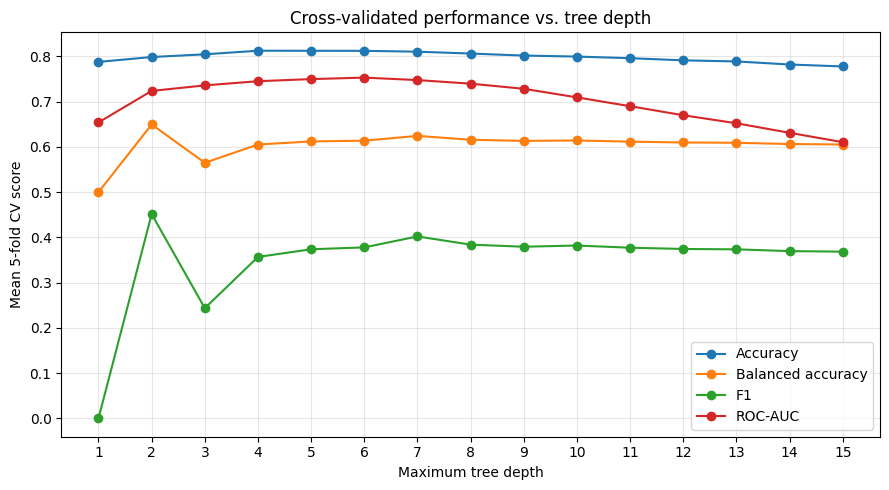

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    depth_results["max_depth"],
    depth_results["cv_accuracy"],
    marker="o",
    label="Accuracy"
)

ax.plot(
    depth_results["max_depth"],
    depth_results["cv_balanced_accuracy"],
    marker="o",
    label="Balanced accuracy"
)

ax.plot(
    depth_results["max_depth"],
    depth_results["cv_f1"],
    marker="o",
    label="F1"
)

ax.plot(
    depth_results["max_depth"],
    depth_results["cv_roc_auc"],
    marker="o",
    label="ROC-AUC"
)

ax.set_xlabel("Maximum tree depth")
ax.set_ylabel("Mean 5-fold CV score")
ax.set_title("Cross-validated performance vs. tree depth")

ax.set_xticks(depth_values)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

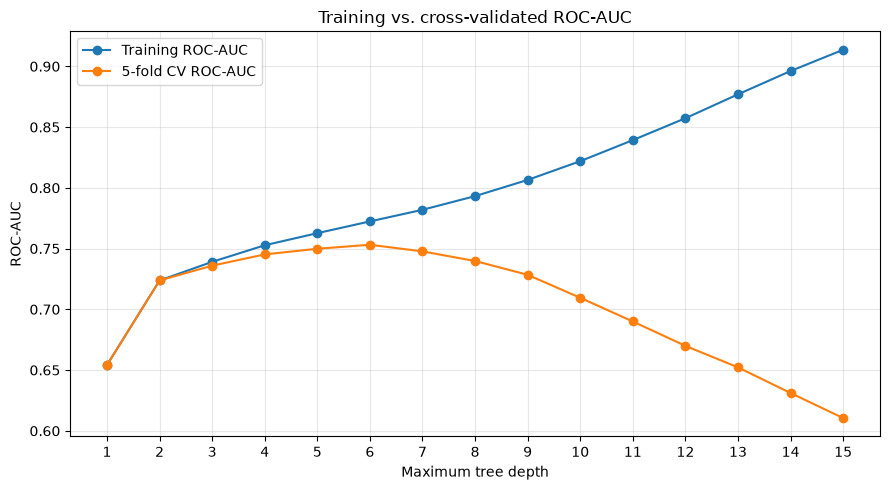

In [51]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    depth_results["max_depth"],
    depth_results["train_roc_auc"],
    marker="o",
    label="Training ROC-AUC"
)

ax.plot(
    depth_results["max_depth"],
    depth_results["cv_roc_auc"],
    marker="o",
    label="5-fold CV ROC-AUC"
)

ax.set_xlabel("Maximum tree depth")
ax.set_ylabel("ROC-AUC")
ax.set_title("Training vs. cross-validated ROC-AUC")

ax.set_xticks(depth_values)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

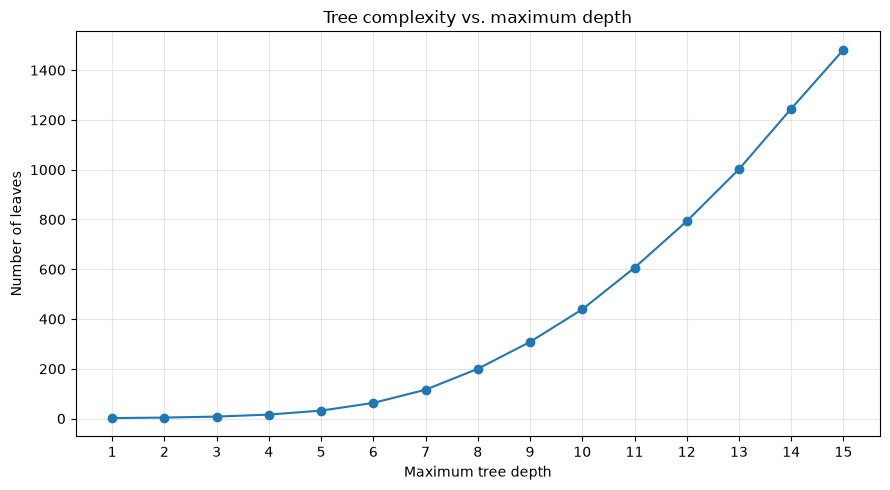

In [52]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    depth_results["max_depth"],
    depth_results["leaves"],
    marker="o"
)

ax.set_xlabel("Maximum tree depth")
ax.set_ylabel("Number of leaves")
ax.set_title("Tree complexity vs. maximum depth")

ax.set_xticks(depth_values)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [53]:
best_auc_row = depth_results.loc[
    depth_results["cv_roc_auc"].idxmax()
]

best_balanced_acc_row = depth_results.loc[
    depth_results["cv_balanced_accuracy"].idxmax()
]

best_f1_row = depth_results.loc[
    depth_results["cv_f1"].idxmax()
]

print("Best depth by ROC-AUC:")
print(
    f"depth={int(best_auc_row['max_depth'])}, "
    f"ROC-AUC={best_auc_row['cv_roc_auc']:.4f}"
)

print("\nBest depth by balanced accuracy:")
print(
    f"depth={int(best_balanced_acc_row['max_depth'])}, "
    f"balanced accuracy="
    f"{best_balanced_acc_row['cv_balanced_accuracy']:.4f}"
)

print("\nBest depth by F1:")
print(
    f"depth={int(best_f1_row['max_depth'])}, "
    f"F1={best_f1_row['cv_f1']:.4f}"
)

Best depth by ROC-AUC:
depth=6, ROC-AUC=0.7532

Best depth by balanced accuracy:
depth=2, balanced accuracy=0.6496

Best depth by F1:
depth=2, F1=0.4515


## 4. Minimum leaf size and model complexity

Maximum depth controls how many consecutive decisions the tree can make, but
it does not directly prevent the model from creating leaves containing very
few observations.

We therefore study `min_samples_leaf`, which specifies the minimum number of
training observations that must remain in each terminal leaf.

Larger values can reduce overfitting and produce rules that apply to broader
groups of observations, potentially improving both generalization and
interpretability.

In [54]:
candidate_depths = [3, 4, 5, 6]

min_leaf_values = [
    1,
    10,
    25,
    50,
    100,
    200,
    500
]

print("Candidate depths:", candidate_depths)
print("Minimum leaf sizes:", min_leaf_values)

Candidate depths: [3, 4, 5, 6]
Minimum leaf sizes: [1, 10, 25, 50, 100, 200, 500]


In [55]:
leaf_results = []

for depth in candidate_depths:
    for min_leaf in min_leaf_values:

        model = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                (
                    "classifier",
                    DecisionTreeClassifier(
                        max_depth=depth,
                        min_samples_leaf=min_leaf,
                        random_state=RANDOM_STATE
                    )
                )
            ]
        )

        scores = cross_validate(
            model,
            X,
            y,
            cv=cv,
            scoring=scoring,
            return_train_score=True,
            n_jobs=-1
        )

        model.fit(X, y)

        fitted_tree = model.named_steps["classifier"]

        leaf_results.append({
            "max_depth": depth,
            "min_samples_leaf": min_leaf,

            "train_accuracy":
                scores["train_accuracy"].mean(),
            "cv_accuracy":
                scores["test_accuracy"].mean(),

            "train_balanced_accuracy":
                scores["train_balanced_accuracy"].mean(),
            "cv_balanced_accuracy":
                scores["test_balanced_accuracy"].mean(),

            "train_f1":
                scores["train_f1"].mean(),
            "cv_f1":
                scores["test_f1"].mean(),

            "train_roc_auc":
                scores["train_roc_auc"].mean(),
            "cv_roc_auc":
                scores["test_roc_auc"].mean(),

            "cv_roc_auc_std":
                scores["test_roc_auc"].std(),

            "actual_depth":
                fitted_tree.get_depth(),
            "leaves":
                fitted_tree.get_n_leaves(),
            "nodes":
                fitted_tree.tree_.node_count
        })

leaf_results = pd.DataFrame(leaf_results)

In [56]:
leaf_results[
    [
        "max_depth",
        "min_samples_leaf",
        "cv_accuracy",
        "cv_balanced_accuracy",
        "cv_f1",
        "cv_roc_auc",
        "cv_roc_auc_std",
        "actual_depth",
        "leaves",
        "nodes"
    ]
].sort_values(
    "cv_roc_auc",
    ascending=False
).round(4)

,max_depth,min_samples_leaf,cv_accuracy,cv_balanced_accuracy,cv_f1,cv_roc_auc,cv_roc_auc_std,actual_depth,leaves,nodes
25,6,100,0.8118,0.6091,0.3664,0.7573,0.0057,6,44,87
24,6,50,0.8114,0.6126,0.3753,0.7558,0.0063,6,46,91
26,6,200,0.8151,0.6163,0.3834,0.7558,0.0039,6,34,67
23,6,25,0.8107,0.6144,0.3800,0.7541,0.0054,6,55,109
22,6,10,0.8115,0.6139,0.3784,0.7538,0.0035,6,61,121
18,5,100,0.8120,0.6097,0.3677,0.7536,0.0050,5,28,55
19,5,200,0.8137,0.6084,0.3642,0.7532,0.0051,5,24,47
27,6,500,0.8133,0.6068,0.3598,0.7532,0.0035,6,23,45
21,6,1,0.8123,0.6138,0.3779,0.7532,0.0044,6,63,125
17,5,50,0.8123,0.6121,0.3736,0.7524,0.0054,5,30,59


In [57]:
auc_matrix = leaf_results.pivot(
    index="min_samples_leaf",
    columns="max_depth",
    values="cv_roc_auc"
)

auc_matrix.round(4)

max_depth,3,4,5,6
min_samples_leaf,,,,
1,0.7359,0.7452,0.7498,0.7532
10,0.7359,0.7452,0.7499,0.7538
25,0.7359,0.7449,0.7509,0.7541
50,0.7361,0.7462,0.7524,0.7558
100,0.7354,0.7470,0.7536,0.7573
200,0.7355,0.7465,0.7532,0.7558
500,0.7374,0.7462,0.7522,0.7532


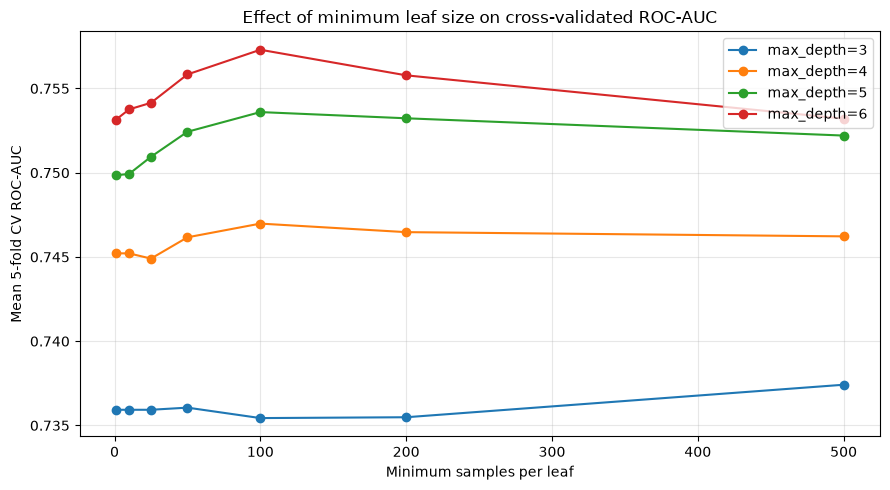

In [58]:
fig, ax = plt.subplots(figsize=(9, 5))

for depth in candidate_depths:
    subset = leaf_results[
        leaf_results["max_depth"] == depth
    ]

    ax.plot(
        subset["min_samples_leaf"],
        subset["cv_roc_auc"],
        marker="o",
        label=f"max_depth={depth}"
    )

ax.set_xlabel("Minimum samples per leaf")
ax.set_ylabel("Mean 5-fold CV ROC-AUC")
ax.set_title(
    "Effect of minimum leaf size on cross-validated ROC-AUC"
)

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [59]:
top_models = (
    leaf_results[
        [
            "max_depth",
            "min_samples_leaf",
            "cv_accuracy",
            "cv_balanced_accuracy",
            "cv_f1",
            "cv_roc_auc",
            "cv_roc_auc_std",
            "leaves",
            "nodes"
        ]
    ]
    .sort_values(
        "cv_roc_auc",
        ascending=False
    )
    .head(10)
    .reset_index(drop=True)
)

top_models.round(4)

,max_depth,min_samples_leaf,cv_accuracy,cv_balanced_accuracy,cv_f1,cv_roc_auc,cv_roc_auc_std,leaves,nodes
0,6,100,0.8118,0.6091,0.3664,0.7573,0.0057,44,87
1,6,50,0.8114,0.6126,0.3753,0.7558,0.0063,46,91
2,6,200,0.8151,0.6163,0.3834,0.7558,0.0039,34,67
3,6,25,0.8107,0.6144,0.3800,0.7541,0.0054,55,109
4,6,10,0.8115,0.6139,0.3784,0.7538,0.0035,61,121
5,5,100,0.8120,0.6097,0.3677,0.7536,0.0050,28,55
6,5,200,0.8137,0.6084,0.3642,0.7532,0.0051,24,47
7,6,500,0.8133,0.6068,0.3598,0.7532,0.0035,23,45
8,6,1,0.8123,0.6138,0.3779,0.7532,0.0044,63,125
9,5,50,0.8123,0.6121,0.3736,0.7524,0.0054,30,59


## 5. Final logical model

The complexity analysis showed that the highest mean cross-validated ROC-AUC
was obtained with `max_depth=6` and `min_samples_leaf=100`.

However, a minimum leaf size of 200 achieved a very similar ROC-AUC while
producing a smaller tree. It also achieved higher cross-validated balanced
accuracy and F1 score, with lower variability in ROC-AUC across folds.

Therefore, the selected logical model uses:

- `max_depth = 6`
- `min_samples_leaf = 200`

This choice reflects the objective of the assignment: obtaining useful
predictive performance while preserving the interpretability of the learned
model.

In [60]:
FINAL_MAX_DEPTH = 6
FINAL_MIN_SAMPLES_LEAF = 200

final_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=FINAL_MAX_DEPTH,
                min_samples_leaf=FINAL_MIN_SAMPLES_LEAF,
                random_state=RANDOM_STATE
            )
        )
    ]
)

final_model.fit(X, y)

final_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['credit_limit','sex','education',...,'zero_payment_months_6m', 'utilization_sep','repayment_assistance_plan']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specif

In [61]:
final_cv = cross_validate(
    final_model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

final_cv_results = pd.DataFrame(final_cv)

final_summary = pd.DataFrame({
    "metric": [
        "accuracy",
        "balanced_accuracy",
        "f1",
        "roc_auc"
    ],
    "train_mean": [
        final_cv_results["train_accuracy"].mean(),
        final_cv_results["train_balanced_accuracy"].mean(),
        final_cv_results["train_f1"].mean(),
        final_cv_results["train_roc_auc"].mean()
    ],
    "cv_mean": [
        final_cv_results["test_accuracy"].mean(),
        final_cv_results["test_balanced_accuracy"].mean(),
        final_cv_results["test_f1"].mean(),
        final_cv_results["test_roc_auc"].mean()
    ],
    "cv_std": [
        final_cv_results["test_accuracy"].std(),
        final_cv_results["test_balanced_accuracy"].std(),
        final_cv_results["test_f1"].std(),
        final_cv_results["test_roc_auc"].std()
    ]
})

final_summary.round(4)

,metric,train_mean,cv_mean,cv_std
0,accuracy,0.8154,0.8151,0.0017
1,balanced_accuracy,0.6168,0.6163,0.0044
2,f1,0.3846,0.3834,0.0103
3,roc_auc,0.7684,0.7558,0.0044


In [62]:
final_tree = final_model.named_steps["classifier"]

print(f"Tree depth:       {final_tree.get_depth()}")
print(f"Number of leaves: {final_tree.get_n_leaves()}")
print(f"Number of nodes:  {final_tree.tree_.node_count}")

Tree depth:       6
Number of leaves: 34
Number of nodes:  67


In [63]:
fitted_preprocessor = final_model.named_steps["preprocessor"]

feature_names = fitted_preprocessor.get_feature_names_out()

print(f"Number of transformed features: {len(feature_names)}")

feature_names

Number of transformed features: 23


array(['sex_female', 'sex_male', 'education_graduate_school',
       'education_high_school', 'education_other', 'education_university',
       'education_unknown', 'marital_status_married',
       'marital_status_other_or_unknown', 'marital_status_single',
       'repayment_assistance_plan_no', 'repayment_assistance_plan_yes',
       'credit_limit', 'age', 'latest_repayment_status',
       'maximum_repayment_delay_6m', 'delayed_months_6m',
       'average_bill_6m', 'bill_change_sep_to_apr', 'total_payment_6m',
       'payment_to_bill_ratio_6m', 'zero_payment_months_6m',
       'utilization_sep'], dtype=object)

In [ ]:
feature_importance = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": final_tree.feature_importances_
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance

,feature,importance
0,latest_repayment_status,0.480364
1,payment_to_bill_ratio_6m,0.259048
2,zero_payment_months_6m,0.089467
3,delayed_months_6m,0.062130
4,utilization_sep,0.037298
5,age,0.026511
6,repayment_assistance_plan_no,0.021995
7,bill_change_sep_to_apr,0.013371
8,repayment_assistance_plan_yes,0.007764
9,credit_limit,0.002051


In [ ]:
used_features = feature_importance[
    feature_importance["importance"] > 0
].copy()

used_features

,feature,importance
0,latest_repayment_status,0.480364
1,payment_to_bill_ratio_6m,0.259048
2,zero_payment_months_6m,0.089467
3,delayed_months_6m,0.062130
4,utilization_sep,0.037298
5,age,0.026511
6,repayment_assistance_plan_no,0.021995
7,bill_change_sep_to_apr,0.013371
8,repayment_assistance_plan_yes,0.007764
9,credit_limit,0.002051


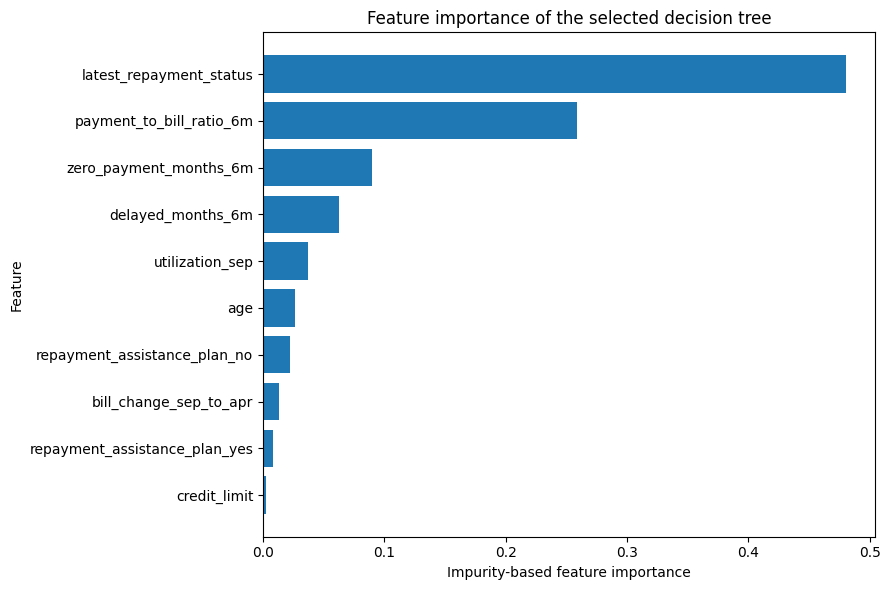

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

plot_data = used_features.sort_values(
    "importance",
    ascending=True
)

ax.barh(
    plot_data["feature"],
    plot_data["importance"]
)

ax.set_xlabel("Impurity-based feature importance")
ax.set_ylabel("Feature")
ax.set_title("Feature importance of the selected decision tree")

plt.tight_layout()
plt.show()

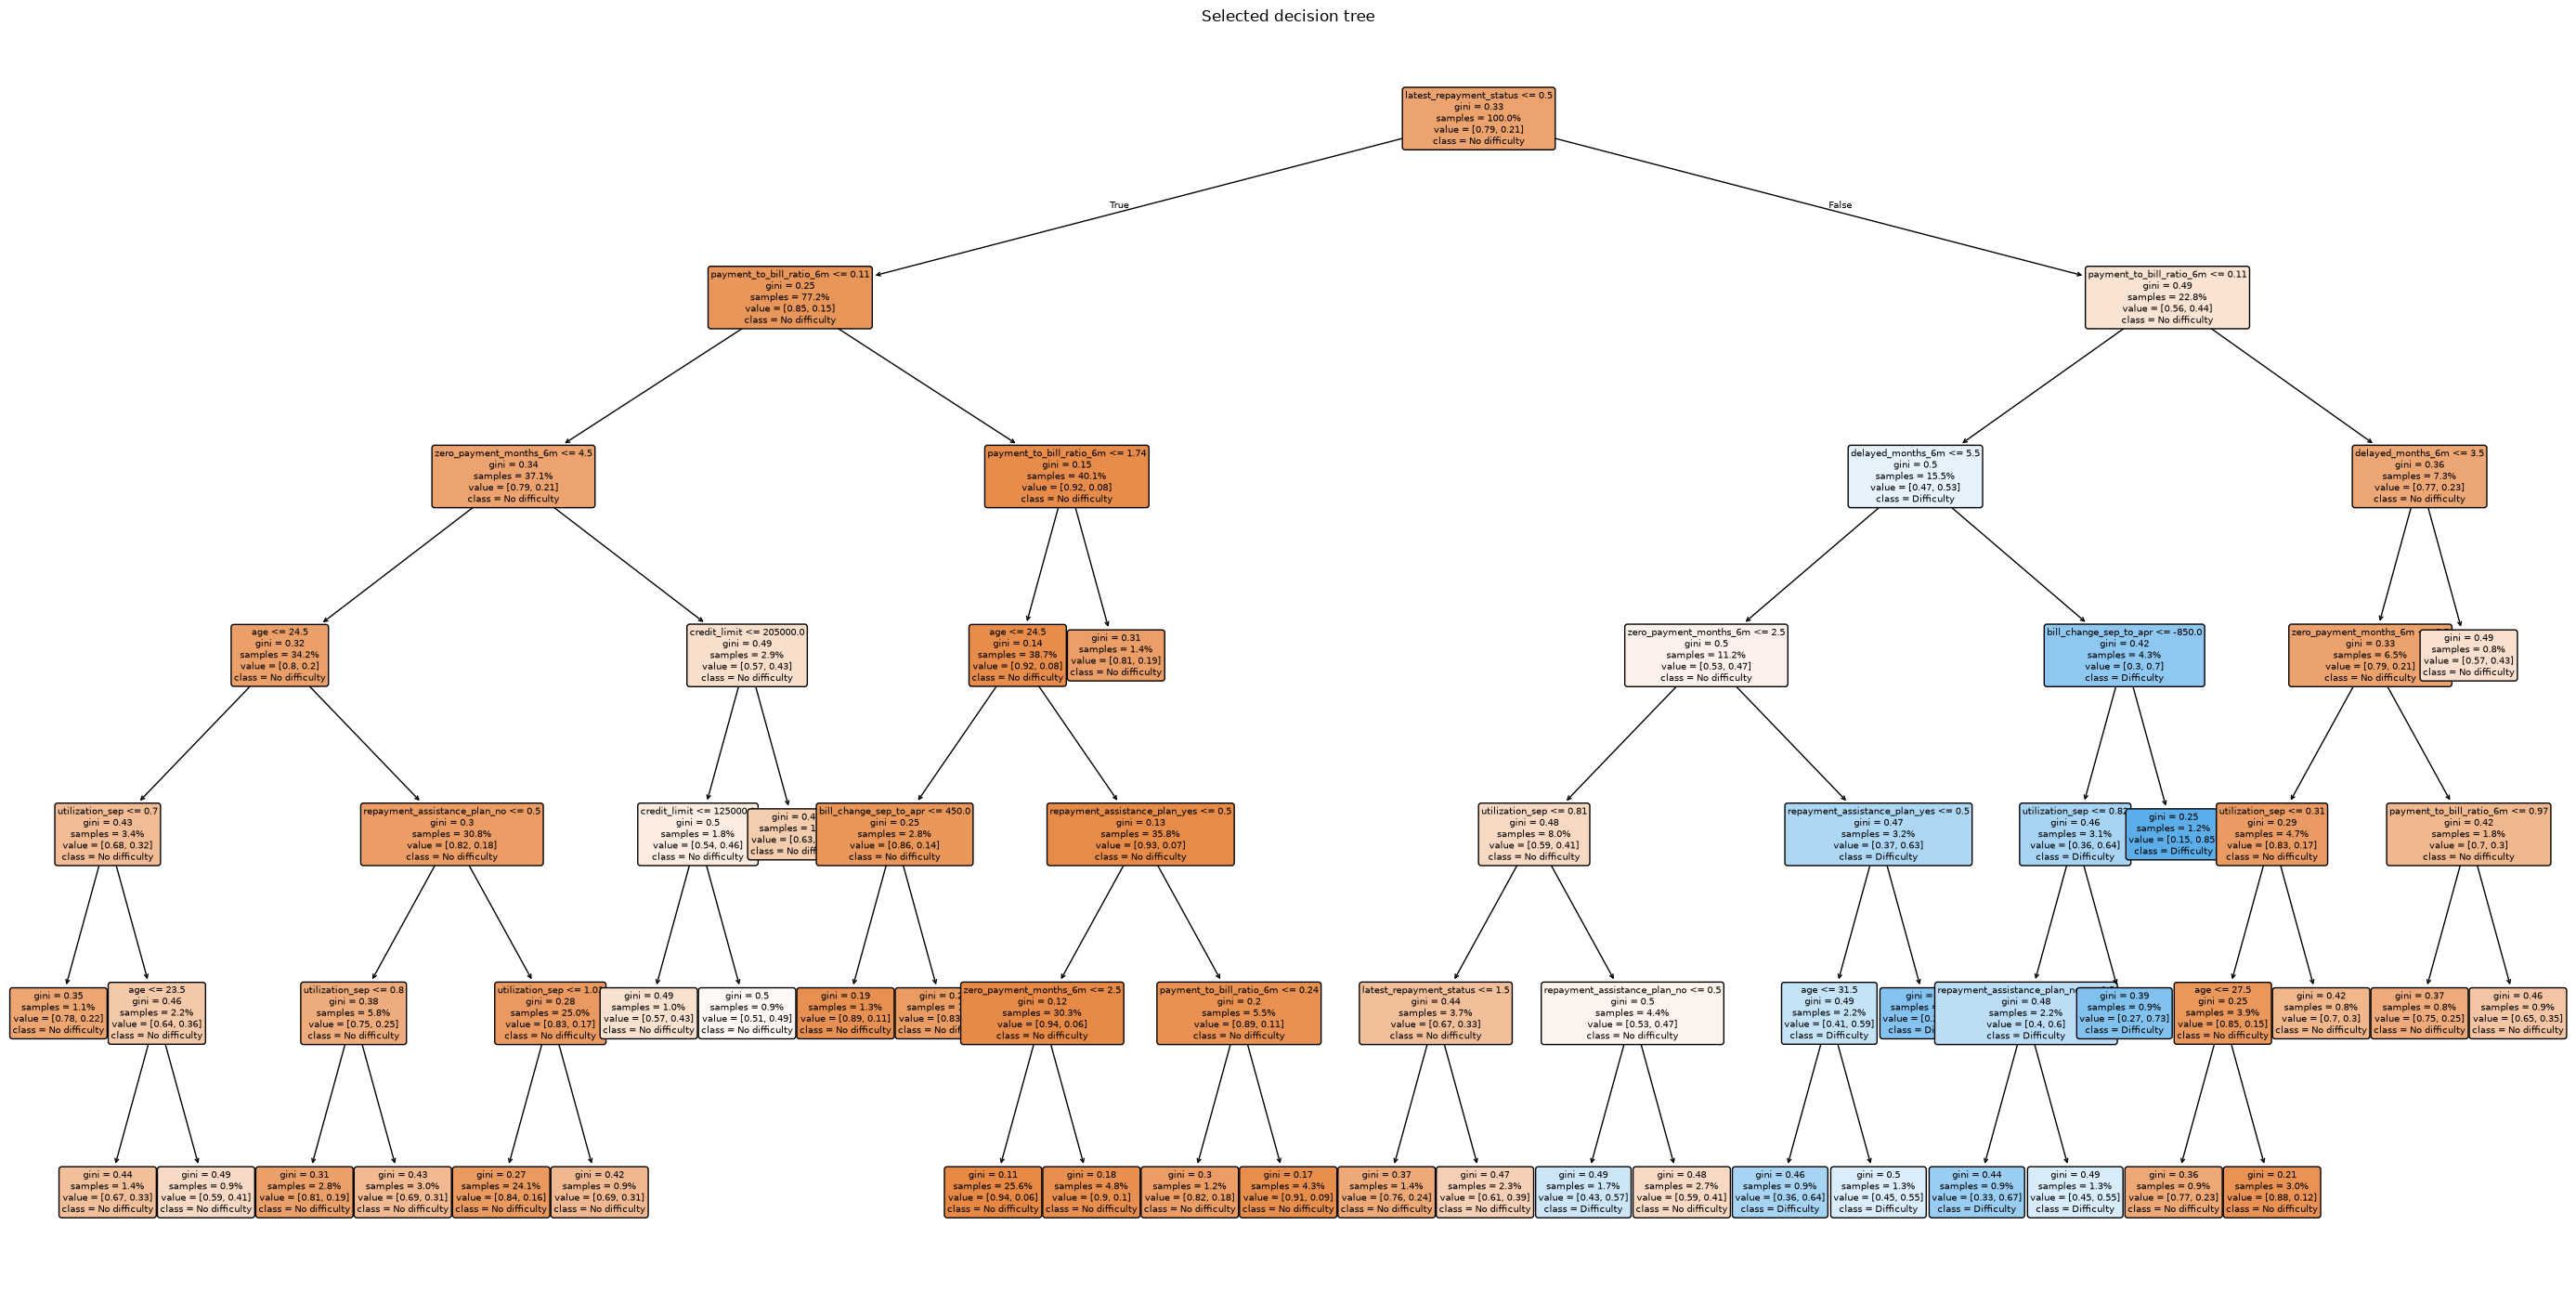

In [66]:
fig, ax = plt.subplots(figsize=(28, 14))

plot_tree(
    final_tree,
    feature_names=feature_names,
    class_names=[
        "No difficulty",
        "Difficulty"
    ],
    filled=True,
    rounded=True,
    proportion=True,
    precision=2,
    fontsize=7,
    ax=ax
)

plt.title("Selected decision tree")

plt.tight_layout()
plt.show()

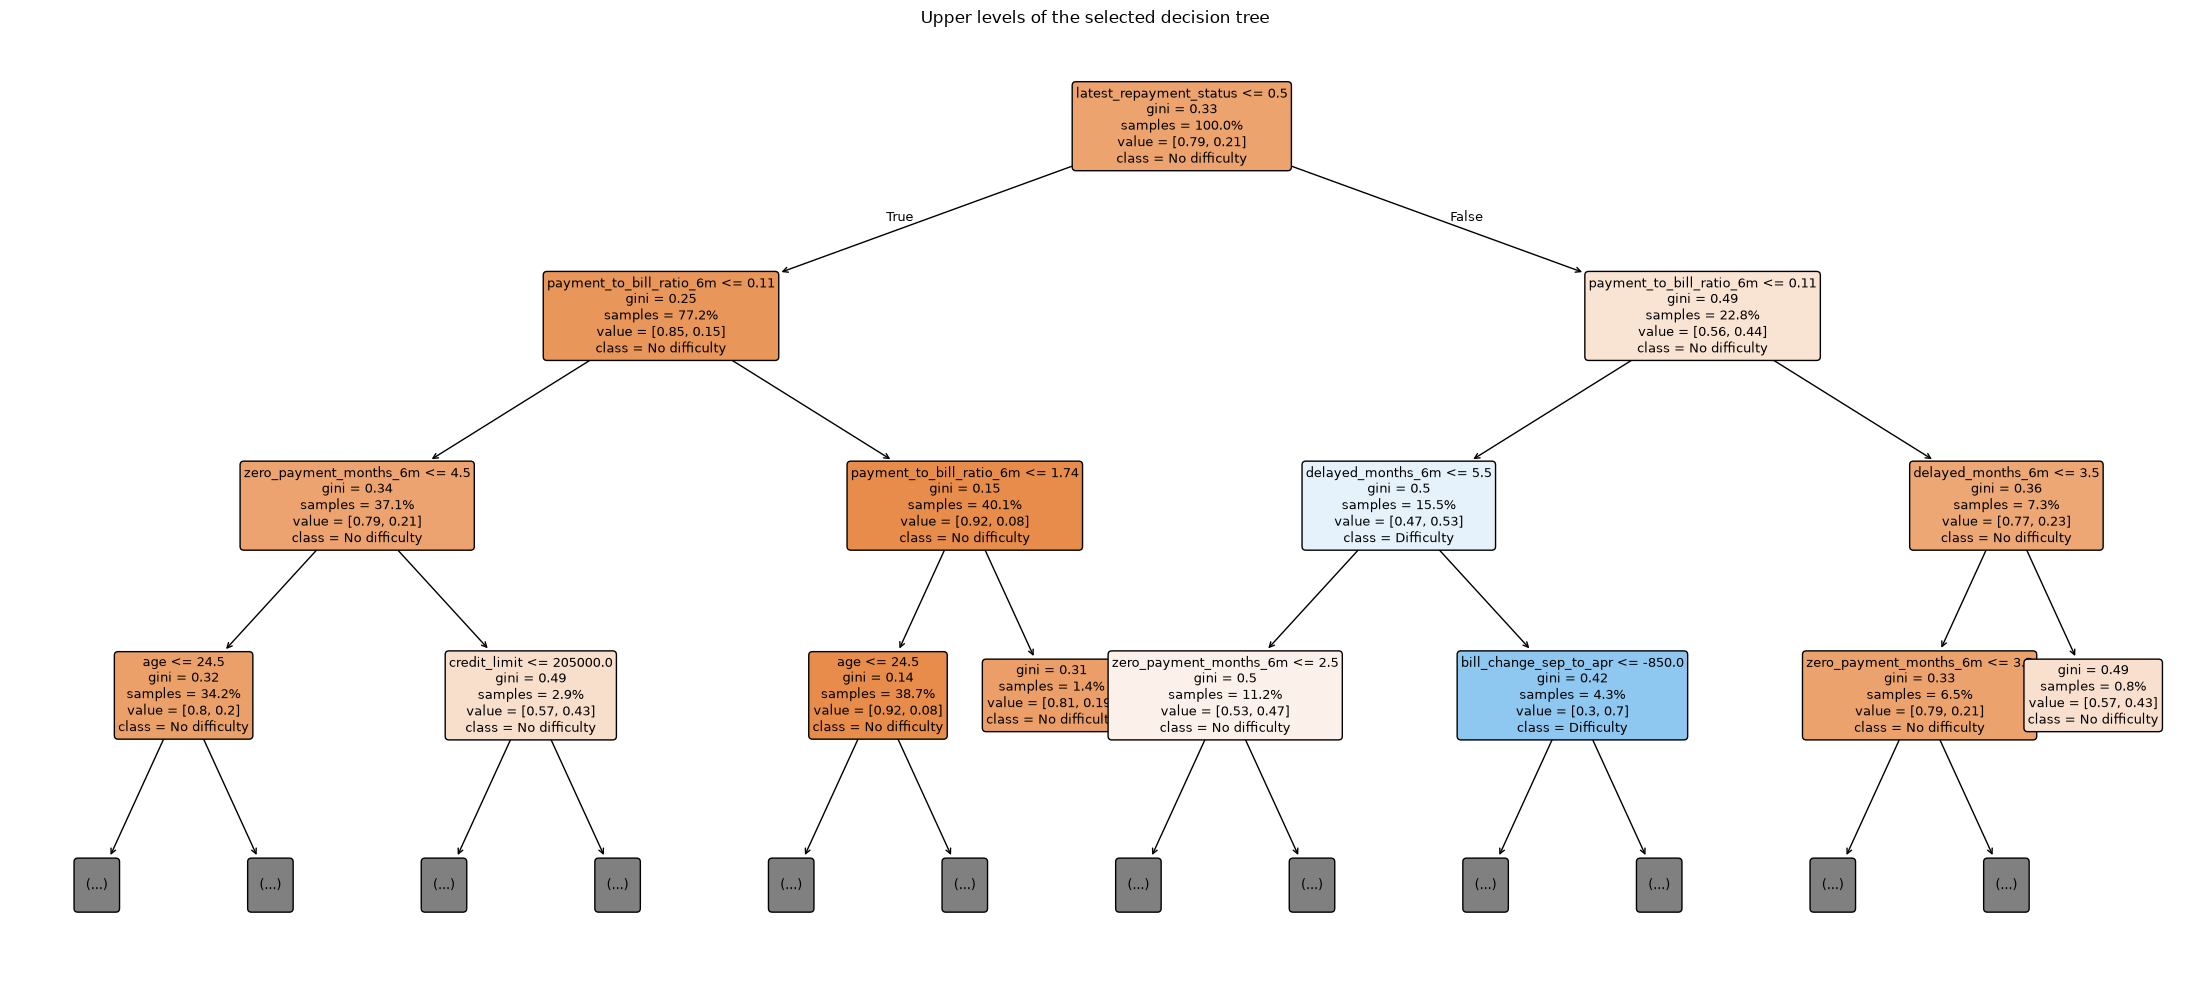

In [67]:
fig, ax = plt.subplots(figsize=(22, 10))

plot_tree(
    final_tree,
    feature_names=feature_names,
    class_names=[
        "No difficulty",
        "Difficulty"
    ],
    filled=True,
    rounded=True,
    proportion=True,
    precision=2,
    max_depth=3,
    fontsize=9,
    ax=ax
)

plt.title("Upper levels of the selected decision tree")

plt.tight_layout()
plt.show()

In [68]:
tree_rules = export_text(
    final_tree,
    feature_names=list(feature_names),
    decimals=3
)

print(tree_rules)

|--- latest_repayment_status <= 0.500
|   |--- payment_to_bill_ratio_6m <= 0.105
|   |   |--- zero_payment_months_6m <= 4.500
|   |   |   |--- age <= 24.500
|   |   |   |   |--- utilization_sep <= 0.705
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- utilization_sep >  0.705
|   |   |   |   |   |--- age <= 23.500
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- age >  23.500
|   |   |   |   |   |   |--- class: 0
|   |   |   |--- age >  24.500
|   |   |   |   |--- repayment_assistance_plan_no <= 0.500
|   |   |   |   |   |--- utilization_sep <= 0.795
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- utilization_sep >  0.795
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- repayment_assistance_plan_no >  0.500
|   |   |   |   |   |--- utilization_sep <= 1.035
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- utilization_sep >  1.035
|   |   |   |   |   |   |--- class: 0
|   |   |--- zero_payment_months_6m >  4.500
|   |   |   |--- 

In [69]:
tree_structure = final_tree.tree_

leaf_nodes = np.where(
    tree_structure.children_left == tree_structure.children_right
)[0]

leaf_data = []

for node_id in leaf_nodes:
    class_counts = tree_structure.value[node_id][0]
    total = class_counts.sum()

    probability_class_1 = (
        class_counts[1] / total
        if total > 0
        else 0
    )

    leaf_data.append({
        "node_id": node_id,
        "samples": tree_structure.n_node_samples[node_id],
        "class_0": class_counts[0],
        "class_1": class_counts[1],
        "probability_class_1": probability_class_1,
        "predicted_class": int(np.argmax(class_counts))
    })

leaf_summary = (
    pd.DataFrame(leaf_data)
    .sort_values(
        "probability_class_1",
        ascending=False
    )
    .reset_index(drop=True)
)

leaf_summary.round(4)

,node_id,samples,class_0,class_1,probability_class_1,predicted_class
0,55,305,0.1475,0.8525,0.8525,1
1,54,213,0.2676,0.7324,0.7324,1
2,48,252,0.2738,0.7262,0.7262,1
3,52,237,0.3291,0.6709,0.6709,1
4,46,214,0.3598,0.6402,0.6402,1
5,42,420,0.4262,0.5738,0.5738,1
6,53,314,0.4459,0.5541,0.5541,1
7,47,333,0.4505,0.5495,0.5495,1
8,19,213,0.5117,0.4883,0.4883,0
9,18,247,0.5668,0.4332,0.4332,0


In [70]:
leaf_summary.head(10).round(4)

,node_id,samples,class_0,class_1,probability_class_1,predicted_class
0,55,305,0.1475,0.8525,0.8525,1
1,54,213,0.2676,0.7324,0.7324,1
2,48,252,0.2738,0.7262,0.7262,1
3,52,237,0.3291,0.6709,0.6709,1
4,46,214,0.3598,0.6402,0.6402,1
5,42,420,0.4262,0.5738,0.5738,1
6,53,314,0.4459,0.5541,0.5541,1
7,47,333,0.4505,0.5495,0.5495,1
8,19,213,0.5117,0.4883,0.4883,0
9,18,247,0.5668,0.4332,0.4332,0


In [71]:
leaf_summary.tail(10).sort_values(
    "probability_class_1"
).round(4)

,node_id,samples,class_0,class_1,probability_class_1,predicted_class
33,28,6390,0.9426,0.0574,0.0574,0
32,32,1069,0.9065,0.0935,0.0935,0
31,29,1193,0.8969,0.1031,0.1031,0
30,24,334,0.8922,0.1078,0.1078,0
29,61,756,0.8783,0.1217,0.1217,0
28,14,6031,0.8382,0.1618,0.1618,0
27,25,378,0.8254,0.1746,0.1746,0
26,31,301,0.8173,0.1827,0.1827,0
25,33,362,0.8122,0.1878,0.1878,0
24,11,703,0.8051,0.1949,0.1949,0


In [72]:
def get_leaf_rule(tree, feature_names, target_node):
    """
    Devuelve la secuencia de decisiones desde la raíz
    hasta una hoja concreta.
    """

    tree_structure = tree.tree_
    path = []

    def recurse(node_id, current_path):
        if node_id == target_node:
            path.extend(current_path)
            return True

        left_child = tree_structure.children_left[node_id]
        right_child = tree_structure.children_right[node_id]

        # Si estamos en una hoja, no podemos continuar
        if left_child == right_child:
            return False

        feature = feature_names[
            tree_structure.feature[node_id]
        ]
        threshold = tree_structure.threshold[node_id]

        # Buscar por la rama izquierda
        if recurse(
            left_child,
            current_path + [
                f"{feature} <= {threshold:.3f}"
            ]
        ):
            return True

        # Buscar por la rama derecha
        if recurse(
            right_child,
            current_path + [
                f"{feature} > {threshold:.3f}"
            ]
        ):
            return True

        return False

    recurse(0, [])

    return path

In [73]:
highest_risk_leaf = int(
    leaf_summary.iloc[0]["node_id"]
)

highest_risk_rule = get_leaf_rule(
    final_tree,
    feature_names,
    highest_risk_leaf
)

print(
    f"Highest-risk leaf: "
    f"{highest_risk_leaf}"
)

print(
    f"Estimated probability of class 1: "
    f"{leaf_summary.iloc[0]['probability_class_1']:.3f}"
)

print(
    f"Training samples in leaf: "
    f"{int(leaf_summary.iloc[0]['samples'])}"
)

print("\nRule:")

for condition in highest_risk_rule:
    print(f"  {condition}")

Highest-risk leaf: 55
Estimated probability of class 1: 0.852
Training samples in leaf: 305

Rule:
  latest_repayment_status > 0.500
  payment_to_bill_ratio_6m <= 0.105
  delayed_months_6m > 5.500
  bill_change_sep_to_apr > -850.000


In [74]:
lowest_risk_leaf = int(
    leaf_summary.iloc[-1]["node_id"]
)

lowest_risk_rule = get_leaf_rule(
    final_tree,
    feature_names,
    lowest_risk_leaf
)

print(
    f"Lowest-risk leaf: "
    f"{lowest_risk_leaf}"
)

print(
    f"Estimated probability of class 1: "
    f"{leaf_summary.iloc[-1]['probability_class_1']:.3f}"
)

print(
    f"Training samples in leaf: "
    f"{int(leaf_summary.iloc[-1]['samples'])}"
)

print("\nRule:")

for condition in lowest_risk_rule:
    print(f"  {condition}")

Lowest-risk leaf: 28
Estimated probability of class 1: 0.057
Training samples in leaf: 6390

Rule:
  latest_repayment_status <= 0.500
  payment_to_bill_ratio_6m > 0.105
  payment_to_bill_ratio_6m <= 1.735
  age > 24.500
  repayment_assistance_plan_yes <= 0.500
  zero_payment_months_6m <= 2.500


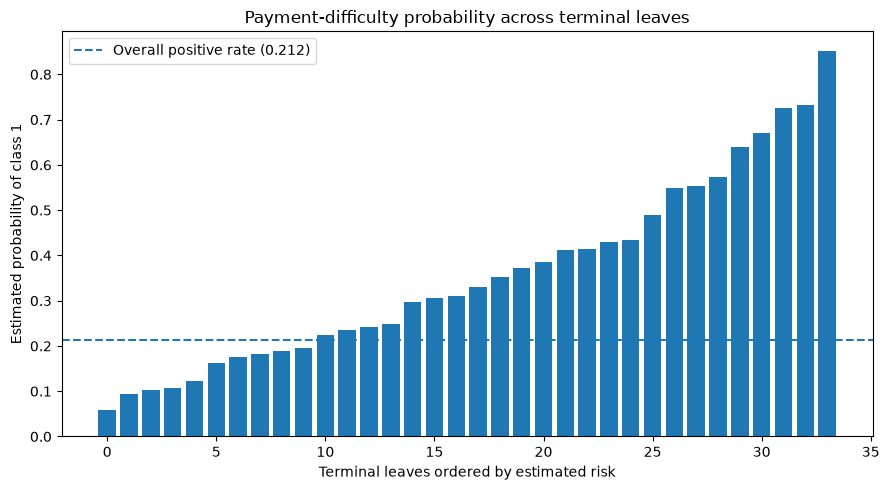

In [75]:
fig, ax = plt.subplots(figsize=(9, 5))

plot_leaf_data = leaf_summary.sort_values(
    "probability_class_1"
).reset_index(drop=True)

ax.bar(
    range(len(plot_leaf_data)),
    plot_leaf_data["probability_class_1"]
)

ax.axhline(
    y=y.mean(),
    linestyle="--",
    label=f"Overall positive rate ({y.mean():.3f})"
)

ax.set_xlabel("Terminal leaves ordered by estimated risk")
ax.set_ylabel("Estimated probability of class 1")
ax.set_title(
    "Payment-difficulty probability across terminal leaves"
)

ax.legend()

plt.tight_layout()
plt.show()

## 6. Global Model Interpretation

Once the decision tree has been selected and trained, we analyze its global
behavior.

The interpretation is based on:

- the importance of the features used by the tree;
- the decisions made at the upper levels of the tree;
- the rules associated with the terminal leaves;
- the estimated probability of payment difficulty in each leaf.

Feature importances and decision rules describe the behavior of the learned
model. They should not be interpreted as causal relationships between the
features and payment difficulty.

## 7. Local Explanations

In addition to the global interpretation of the tree, we analyze individual
predictions.

To avoid selecting examples based only on predictions made on the same data
used to train the model, we first obtain out-of-fold predictions using
five-fold cross-validation.

Two representative observations are selected:

- one observation whose true class is 0;
- one observation whose true class is 1.

These same cases will be retained for the subsequent comparison of the
explanations provided by the different models.

In [79]:
from sklearn.model_selection import cross_val_predict

oof_probabilities = cross_val_predict(
    final_model,
    X,
    y,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

oof_predictions = (oof_probabilities >= 0.5).astype(int)

oof_results = pd.DataFrame({
    "row_id": train[ID_COLUMN],
    "true_class": y.values,
    "predicted_class": oof_predictions,
    "probability_class_1": oof_probabilities
})

oof_results.head()

,row_id,true_class,predicted_class,probability_class_1
0,CR26-120473,0,0,0.141308
1,CR26-127004,0,0,0.155782
2,CR26-116408,0,0,0.061654
3,CR26-125768,0,0,0.157443
4,CR26-118040,0,0,0.146801


In [81]:
print(
    f"Accuracy:          "
    f"{accuracy_score(y, oof_predictions):.4f}"
)

print(
    f"Balanced accuracy: "
    f"{balanced_accuracy_score(y, oof_predictions):.4f}"
)

print(
    f"F1:                "
    f"{f1_score(y, oof_predictions):.4f}"
)

print(
    f"ROC-AUC:           "
    f"{roc_auc_score(y, oof_probabilities):.4f}"
)

print("\nMatriz de confusión:")
print(confusion_matrix(y, oof_predictions))

Accuracy:          0.8151
Balanced accuracy: 0.6163
F1:                0.3835
ROC-AUC:           0.7557

Matriz de confusión:
[[18939   758]
 [ 3865  1438]]


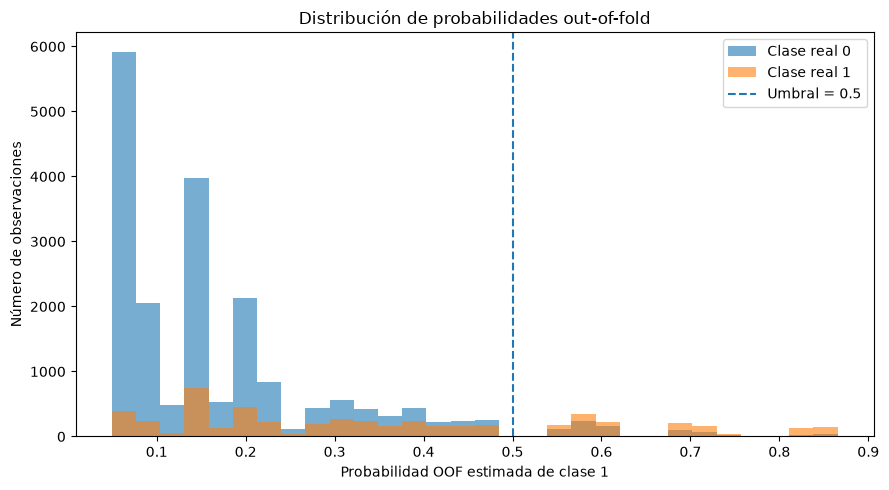

In [83]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    oof_results.loc[
        oof_results["true_class"] == 0,
        "probability_class_1"
    ],
    bins=30,
    alpha=0.6,
    label="Clase real 0"
)

ax.hist(
    oof_results.loc[
        oof_results["true_class"] == 1,
        "probability_class_1"
    ],
    bins=30,
    alpha=0.6,
    label="Clase real 1"
)

ax.axvline(
    0.5,
    linestyle="--",
    label="Umbral = 0.5"
)

ax.set_xlabel("Probabilidad OOF estimada de clase 1")
ax.set_ylabel("Número de observaciones")
ax.set_title("Distribución de probabilidades out-of-fold")

ax.legend()

plt.tight_layout()
plt.show()

In [84]:
correct_oof = oof_results[
    oof_results["true_class"]
    == oof_results["predicted_class"]
].copy()

selected_cases = []

for target_class in [0, 1]:

    candidates = correct_oof[
        correct_oof["true_class"] == target_class
    ].copy()

    median_probability = candidates[
        "probability_class_1"
    ].median()

    candidates["distance_to_median"] = (
        candidates["probability_class_1"]
        - median_probability
    ).abs()

    selected_case = candidates.sort_values(
        "distance_to_median"
    ).iloc[0]

    selected_cases.append(selected_case)

selected_cases = pd.DataFrame(
    selected_cases
).reset_index(drop=True)

selected_cases

,row_id,true_class,predicted_class,probability_class_1,distance_to_median
0,CR26-122402,0,0,0.142004,0.0
1,CR26-106598,1,1,0.604444,0.0


In [85]:
selected_row_ids = selected_cases["row_id"].tolist()

selected_instances = train[
    train[ID_COLUMN].isin(selected_row_ids)
].copy()

selected_instances

,row_id,credit_limit,sex,education,marital_status,age,latest_repayment_status,maximum_repayment_delay_6m,delayed_months_6m,average_bill_6m,bill_change_sep_to_apr,total_payment_6m,payment_to_bill_ratio_6m,zero_payment_months_6m,utilization_sep,repayment_assistance_plan,payment_difficulty_next_month
14844,CR26-106598,30000,male,university,married,33,1,1,1,0,0,0,0.00,6,0.00,no,1
19228,CR26-122402,40000,female,graduate_school,single,27,0,0,0,12400,-4800,6400,0.09,1,0.24,no,0


In [ ]:
X_selected = selected_instances.drop(
    columns=[ID_COLUMN, TARGET]
)

final_probabilities = final_model.predict_proba(
    X_selected
)[:, 1]

final_predictions = final_model.predict(
    X_selected
)

local_predictions = selected_instances[
    [ID_COLUMN, TARGET]
].copy()

local_predictions[
    "predicted_class"
] = final_predictions

local_predictions[
    "probability_class_1"
] = final_probabilities

local_predictions

,row_id,payment_difficulty_next_month,predicted_class,probability_class_1
14844,CR26-106598,1,1,0.549550
19228,CR26-122402,0,0,0.161831


In [ ]:
X_selected_transformed = (
    final_model
    .named_steps["preprocessor"]
    .transform(X_selected)
)

assigned_leaves = final_tree.apply(
    X_selected_transformed
)

local_predictions[
    "leaf_node"
] = assigned_leaves

local_predictions

,row_id,payment_difficulty_next_month,predicted_class,probability_class_1,leaf_node
14844,CR26-106598,1,1,0.549550,47
19228,CR26-122402,0,0,0.161831,14


In [ ]:
for _, row in local_predictions.iterrows():

    row_id = row[ID_COLUMN]
    leaf_node = int(row["leaf_node"])

    rule = get_leaf_rule(
        final_tree,
        feature_names,
        leaf_node
    )

    print("=" * 70)
    print(f"Observación: {row_id}")
    print(f"Clase real: {int(row[TARGET])}")
    print(
        f"Predicción: "
        f"{int(row['predicted_class'])}"
    )
    print(
        f"P(clase 1): "
        f"{row['probability_class_1']:.3f}"
    )
    print(f"Hoja: {leaf_node}")

    print("\nCamino de decisión:")

    for condition in rule:
        print(f"  {condition}")

    print()

Observación: CR26-106598
Clase real: 1
Predicción: 1
P(clase 1): 0.550
Hoja: 47

Camino de decisión:
  latest_repayment_status > 0.500
  payment_to_bill_ratio_6m <= 0.105
  delayed_months_6m <= 5.500
  zero_payment_months_6m > 2.500
  repayment_assistance_plan_yes <= 0.500
  age > 31.500

Observación: CR26-122402
Clase real: 0
Predicción: 0
P(clase 1): 0.162
Hoja: 14

Camino de decisión:
  latest_repayment_status <= 0.500
  payment_to_bill_ratio_6m <= 0.105
  zero_payment_months_6m <= 4.500
  age > 24.500
  repayment_assistance_plan_no > 0.500
  utilization_sep <= 1.035



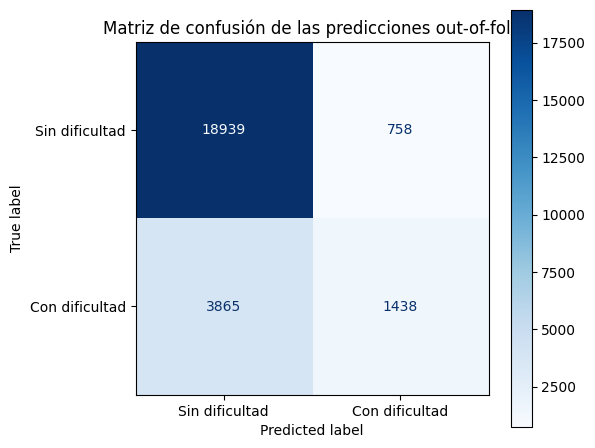

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y,
    oof_predictions,
    display_labels=[
        "Sin dificultad",
        "Con dificultad"
    ],
    cmap="Blues",
    ax=ax
)

ax.set_title(
    "Matriz de confusión de las predicciones out-of-fold"
)

plt.tight_layout()
plt.show()

In [ ]:
print(
    classification_report(
        y,
        oof_predictions,
        target_names=[
            "Sin dificultad",
            "Con dificultad"
        ],
        digits=4
    )
)

                precision    recall  f1-score   support

Sin dificultad     0.8305    0.9615    0.8912     19697
Con dificultad     0.6548    0.2712    0.3835      5303

      accuracy                         0.8151     25000
     macro avg     0.7427    0.6163    0.6374     25000
  weighted avg     0.7932    0.8151    0.7835     25000



In [ ]:
results_table = pd.DataFrame({
    "Clasificador": [
        "DecisionTreeClassifier"
    ],
    "Configuración principal": [
        "max_depth=6, min_samples_leaf=200"
    ],
    "Accuracy CV": [
        final_cv_results["test_accuracy"].mean()
    ],
    "Balanced accuracy CV": [
        final_cv_results[
            "test_balanced_accuracy"
        ].mean()
    ],
    "F1 CV": [
        final_cv_results["test_f1"].mean()
    ],
    "ROC-AUC CV": [
        final_cv_results["test_roc_auc"].mean()
    ],
    "ROC-AUC std": [
        final_cv_results["test_roc_auc"].std()
    ]
})

results_table.round(4)

,Clasificador,Configuración principal,Accuracy CV,Balanced accuracy CV,F1 CV,ROC-AUC CV,ROC-AUC std
0,DecisionTreeClassifier,"max_depth=6, min_samples_leaf=200",0.8151,0.6163,0.3834,0.7558,0.0044


## 8. Preliminary Discussion

The unrestricted decision tree showed substantial overfitting, achieving
almost perfect performance on the training data but a mean ROC-AUC of
approximately 0.595 under cross-validation. In addition, the resulting tree
contained 8,911 nodes and 4,456 leaves, making it considerably more difficult
to interpret.

Restricting model complexity improved both generalization and interpretability.
The final selected model uses a maximum depth of 6 and a minimum of 200
observations per leaf. This model achieves a mean ROC-AUC of approximately
0.756 under five-fold cross-validation, with a standard deviation of
approximately 0.004.

The model relies mainly on information related to payment behavior. The
features with the highest impurity-based importance are
`latest_repayment_status` and `payment_to_bill_ratio_6m`, followed by
`zero_payment_months_6m`, `delayed_months_6m`, and `utilization_sep`.

The learned rules identify regions with substantially different payment
difficulty profiles. For example, the leaf with the highest estimated
probability of payment difficulty contains 305 observations and has a positive
class proportion of approximately 0.853, whereas the leaf with the lowest
estimated probability contains 6,390 observations and has a positive class
proportion of approximately 0.057.

These associations describe the predictive behavior of the tree and should not
be interpreted as causal relationships. This is particularly relevant for
features such as `repayment_assistance_plan`, whose presence may be associated
with prior information about the customer's situation.

Finally, model performance also depends on the classification threshold. Using
the default threshold of 0.5, the model achieves relatively high accuracy but
has difficulty identifying a substantial proportion of positive-class
observations. Any modification of the classification threshold should be
selected through cross-validation rather than using the test set.

### Selected Cases for Local Explanations

To facilitate a subsequent comparison between models, the following
observations will be retained:

- **CR26-106598**: true class 1. The final decision tree predicts class 1 with
  an estimated probability of approximately 0.550.
- **CR26-122402**: true class 0. The final decision tree predicts class 0 with
  an estimated probability of class 1 of approximately 0.162.

The same cases will subsequently be used to analyze and compare the local
explanations produced by the different models.